<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/cybersecurity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import samplers
importlib.reload(samplers)
from samplers import metropolis_hastings_log, composite_transition
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import random
import networkx as nx

Cloning into 'MCMC-MonteCarlo-TFG'...
remote: Enumerating objects: 204, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 204 (delta 33), reused 4 (delta 4), pack-reused 145 (from 1)
Receiving objects: 100% (204/204), 4.80 MiB | 10.72 MiB/s, done.
Resolving deltas: 100% (94/94), done.


In [2]:
rng = np.random.default_rng(seed = 1)

nodes = 2000
# Red Barabási-Albert simula bien la topología de internet/corporativa (pocos hubs, muchos nodos terminales)
# G = nx.barabasi_albert_graph(n=nodes, m=2, seed=1)

# k: Cada nodo se conecta a sus 'k' vecinos más cercanos (debe ser un número par)
# p: Probabilidad de reconectar un cable al azar (crea los puentes entre departamentos)
G = nx.watts_strogatz_graph(n=nodes, k=4, p=0.1, seed=1)
# Calculamos las distancias más cortas entre todos los pares de nodos (Matriz de distancias)
distancias = dict(nx.all_pairs_shortest_path_length(G))

# Simulamos la infección real
nodo_cero_real = random.choice(list(G.nodes()))
velocidad_propagacion = 30 # Tiempo que tarda en saltar de un nodo a otro

# Tiempos teóricos de infección para toda la red
T_real = {nodo: distancias[nodo_cero_real][nodo] * velocidad_propagacion for nodo in G.nodes()}

# Visibilidad Parcial (El equipo de seguridad solo ve una parte)
ratio_observacion = 0.3 # Solo tienen antivirus/logs el 30% de las máquinas
nodos_observados = random.sample(list(G.nodes()), int(nodes * ratio_observacion))

# Añadimos un poco de ruido a las alarmas (retrasos de red, etc)
T_obs = {nodo: max(0, T_real[nodo] + rng.normal(0, 0.5)) for nodo in nodos_observados}

In [3]:
# Para el "Salto Inteligente", calculamos una probabilidad a priori basada en:
# 1. Nodos que se infectaron muy pronto (bajos T_obs)
# 2. Centralidad de grado (nodos muy conectados)

# Esta métrica es a prueba de balas para CUALQUIER tipo de grafo.
# No busca al que tiene más conexiones, sino al que actúa más veces
# como "puente" en las rutas más cortas de la red.
centralidad = nx.betweenness_centrality(G)
probabilidades_salto = np.zeros(nodes)

tiempo_minimo_obs = min(T_obs.values())
for nodo in G.nodes():
    # Estimamos qué tan "temprano" pudo caer este nodo evaluando sus vecinos observados
    dist_a_obs = [distancias[nodo][obs] for obs in nodos_observados]

    score_centralidad = centralidad[nodo]

    # Si el nodo está cerca de los que se detectaron primero, recibe más peso
    peso_cercania = 1.0 / (1.0 + min(dist_a_obs))

    probabilidades_salto[nodo] = score_centralidad * peso_cercania

# Normalizamos para crear una distribución de probabilidad
probabilidades_salto = probabilidades_salto / np.sum(probabilidades_salto)


In [4]:
# Definimos la energía
def log_target_pdf(current_state):
    # En este contexto, el estado actual es el nodo que estamos evaluando
    nodo_hipotesis = current_state

    error_total = 0

    for obs_nodo, t_obs in T_obs.items():
        # Distancia en saltos desde el nodo que estamos evaluando hasta el sensor
        d = distancias[nodo_hipotesis][obs_nodo]

        # Tiempo teórico que habría tardado en llegar
        t_teorico = d * velocidad_propagacion

        # Sumamos el error cuadrático
        error_total += (t_obs - t_teorico)**2

    # IMPORTANTE: Como es un "log_target_pdf", devolvemos el error en NEGATIVO.
    # Minimizar el error_total es equivalente a maximizar el -error_total.
    # Si añadieras la varianza del ruido (sigma=0.5), sería: return -error_total / (2 * 0.5**2)
    return -error_total

def sampler_dirigido(nodo_actual, rng):
    # Usamos el rng que pasamos por parámetro
    return rng.choice(G.nodes(), p=probabilidades_salto)

def sampler_random_walk(nodo_actual, rng):
    vecinos = list(G.neighbors(nodo_actual))
    return rng.choice(vecinos)

# Generamos la propuesta usando la composición de trancisiones

# Agrupamos las funciones base
base_transitions = [sampler_random_walk, sampler_dirigido]

# Definimos el vector de probabilidades
alphas = [0.85, 0.15]

# Fabricamos la transición compuesta
proposal_sampler = composite_transition(base_transitions, alphas)

def log_proposal_pdf(proposed_state, current_state, alpha_1=0.15):
    # 1. Probabilidad de la propuesta dirigida (independiente del estado actual)
    p_dirigido = probabilidades_salto[proposed_state]

    # 2. Probabilidad de la caminata aleatoria (depende de los vecinos)
    vecinos_current = list(G.neighbors(current_state))

    if proposed_state in vecinos_current:
        # Si es un vecino, la probabilidad de elegirlo al azar es 1 / n_vecinos
        p_rw = 1.0 / len(vecinos_current)
    else:
        # Si no es vecino, la caminata aleatoria pura jamás habría llegado aquí
        p_rw = 0.0

    # 3. Combinamos ambas probabilidades usando la misma proporción que en tu ciclo
    p_total = (alpha_1 * p_dirigido) + ((1.0 - alpha_1) * p_rw)

    # 4. Retornamos el logaritmo
    # Añadimos un valor infinitesimal (1e-12) para evitar hacer np.log(0)
    # en caso de que p_total sea exactamente 0.
    eps = 1e-12
    return np.log(p_total + eps)

initial = np.random.choice(G.nodes())
iterations=15000 # Número de iteraciones

# Ejecutamos el algoritmo de Metropolis Hastings
initial = np.random.choice(G.nodes())
iterations = 15000

# Capturamos el historial_estados devuelto
nodo_inferido, historial_energia, historial_estados = metropolis_hastings_log(initial, log_target_pdf, proposal_sampler, log_proposal_pdf, iterations)

In [5]:
def motor_inferencia_predictiva_tti(historial_estados, nodos_criticos, T_now):
    # 1. Descartar el período de calentamiento (Burn-in)
    burn_in = int(len(historial_estados) * 0.3)
    muestras_validas = historial_estados[burn_in:]

    tiempos_restantes = []
    nodos_en_peligro = []

    # 2. Explorar el multiverso para encontrar el Tiempo Mínimo
    for posible_origen in muestras_validas:
        tiempo_minimo_simulacion = float('inf')
        servidor_mas_cercano = None

        for servidor in nodos_criticos:
            # Calculamos a qué hora exacta llegará el malware a este servidor
            tiempo_llegada = distancias[posible_origen][servidor] * velocidad_propagacion

            # Solo nos importa si el servidor AÚN no ha sido infectado
            if tiempo_llegada > T_now:
                tiempo_restante = tiempo_llegada - T_now

                # Buscamos cuál es el servidor que caerá PRIMERO en esta simulación
                if tiempo_restante < tiempo_minimo_simulacion:
                    tiempo_minimo_simulacion = tiempo_restante
                    servidor_mas_cercano = servidor

        # 3. Si en esta simulación hay un impacto futuro, guardamos el tiempo y la ruta
        if servidor_mas_cercano is not None:
            tiempos_restantes.append(tiempo_minimo_simulacion)

            # Extraemos la ruta hacia ESE servidor específico (el que caerá primero)
            ruta = nx.shortest_path(G, source=posible_origen, target=servidor_mas_cercano)

            for nodo_paso in ruta:
                tiempo_llegada_paso = distancias[posible_origen][nodo_paso] * velocidad_propagacion
                if tiempo_llegada_paso > T_now and nodo_paso not in nodos_criticos:
                    nodos_en_peligro.append(nodo_paso)

    # Si la lista está vacía, o los servidores ya cayeron o no hay rutas viables
    if not tiempos_restantes:
        return None, None, []

    # 4. Agregación de resultados probabilísticos
    # Obtenemos el peor escenario (el malware va súper rápido) y el escenario esperado (promedio)
    tti_peor_escenario = np.min(tiempos_restantes)
    tti_esperado = np.mean(tiempos_restantes)

    # Identificar los cuellos de botella
    conteo_nodos = Counter(nodos_en_peligro)
    total_rutas_peligro = sum(conteo_nodos.values())

    nodos_a_aislar = []
    rutas_bloqueadas_acumuladas = 0

    # Recorremos los cuellos de botella de mayor a menor tráfico malicioso
    for nodo, frecuencia in conteo_nodos.most_common():
        nodos_a_aislar.append((nodo, frecuencia))
        rutas_bloqueadas_acumuladas += frecuencia

        # Si ya hemos cortado el 90% de las vías de acceso del malware, paramos
        # Se añade "total_rutas_peligro > 0" para evitar ZeroDivisionError
        if total_rutas_peligro > 0 and (rutas_bloqueadas_acumuladas / total_rutas_peligro) >= 0.90:
            break

    # Retornamos la lista dinámica y los tiempos corregidos
    return tti_peor_escenario, tti_esperado, nodos_a_aislar

    # 1. Calculamos la centralidad de grado
centralidad = nx.degree_centrality(G)

# 2. Ordenamos los nodos de mayor a menor cantidad de conexiones
nodos_ordenados = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)

# 3. Extraemos automáticamente los 3 nodos más conectados ("Las Joyas de la Corona")
servidores_criticos = [nodo for nodo, score in nodos_ordenados[:3]]

# 4. Punto de inflexión temporal: Actuamos cuando llega el 40% de las alertas
tiempos_alertas = sorted(T_obs.values())
indice_reaccion = int(len(tiempos_alertas) * 0.40)
tiempo_actual = tiempos_alertas[indice_reaccion]

print(f"[*] El equipo inicia la contención en T={tiempo_actual:.2f}")

# 5. Ejecutamos el motor predictivo
peor_escenario, tiempo_esperado, nodos_a_aislar = motor_inferencia_predictiva_tti(
    historial_estados,
    servidores_criticos,
    T_now=tiempo_actual
)

print("\n🚨 [SISTEMA PREDICTIVO DE RESPUESTA A INCIDENTES] 🚨")
if peor_escenario is None:
    print("Estado: Los servidores críticos ya han sido comprometidos o son inalcanzables.")
else:
    print(f"⏱️ TIEMPO ESTIMADO HASTA IMPACTO (TTI): {tiempo_esperado:.2f} unidades de tiempo.")
    print(f"⚠️ PEOR ESCENARIO POSIBLE (Worst-Case): {peor_escenario:.2f} unidades de tiempo.")
    print("\nAcción defensiva recomendada - Cortafuegos de Emergencia:")

    for nodo, frecuencia in nodos_a_aislar:
        porcentaje_intercepcion = (frecuencia / len(historial_estados)) * 100
        print(f" -> Desconectar Nodo {nodo} (Intercepta el {porcentaje_intercepcion:.1f}% de las amenazas proyectadas)")

[*] El equipo inicia la contención en T=299.89

🚨 [SISTEMA PREDICTIVO DE RESPUESTA A INCIDENTES] 🚨
⏱️ TIEMPO ESTIMADO HASTA IMPACTO (TTI): 60.11 unidades de tiempo.
⚠️ PEOR ESCENARIO POSIBLE (Worst-Case): 60.11 unidades de tiempo.

Acción defensiva recomendada - Cortafuegos de Emergencia:
 -> Desconectar Nodo 1269 (Intercepta el 70.0% de las amenazas proyectadas)
 -> Desconectar Nodo 1271 (Intercepta el 70.0% de las amenazas proyectadas)


--- RESULTADOS INFERENCIA MCMC ---
Nodo Cero Real     : 1018
Nodo Cero Inferido : 1018
Distancia en saltos entre inferido y real: 0


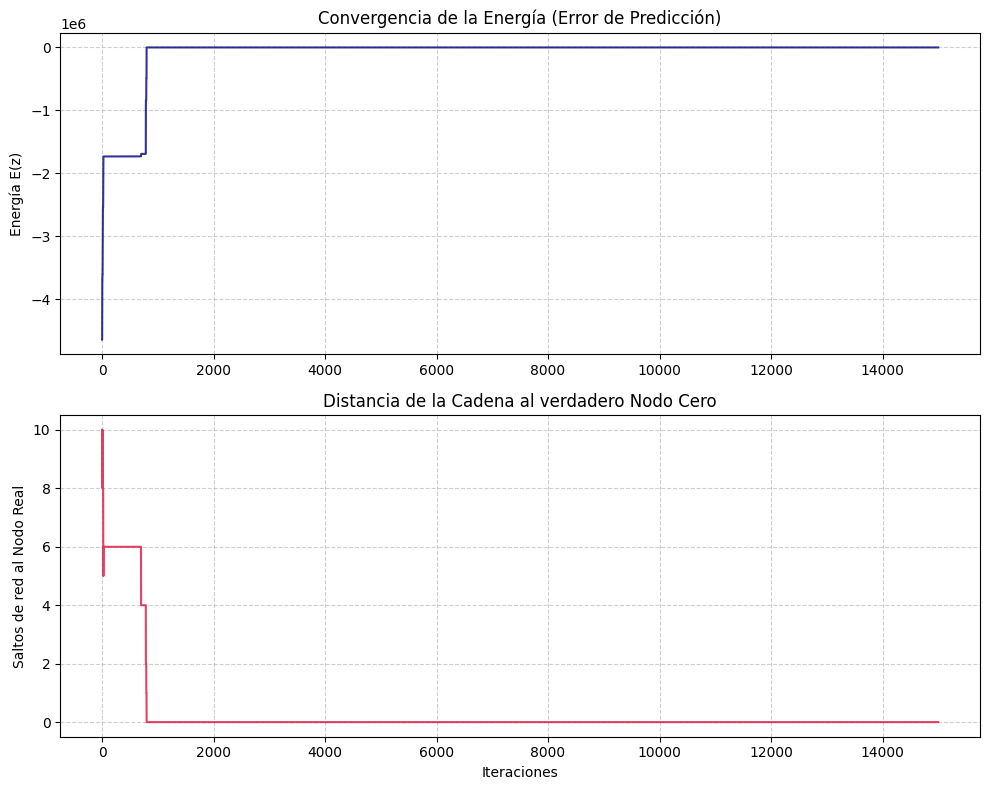

In [12]:
print("--- RESULTADOS INFERENCIA MCMC ---")
print(f"Nodo Cero Real     : {nodo_cero_real}")
print(f"Nodo Cero Inferido : {nodo_inferido}")
print(f"Distancia en saltos entre inferido y real: {distancias[nodo_inferido][nodo_cero_real]}")

# Calcular dist_hist a partir de historial_estados
dist_hist = [distancias[estado][nodo_cero_real] for estado in historial_estados]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Gráfica 1: Energía
ax1.plot(historial_energia, color='navy', alpha=0.8)
ax1.set_title('Convergencia de la Energía (Error de Predicción)', fontsize=12)
ax1.set_ylabel('Energía E(z)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Precisión real (Distancia al verdadero Nodo 0)
ax2.plot(dist_hist, color='crimson', alpha=0.8)
ax2.set_title('Distancia de la Cadena al verdadero Nodo Cero', fontsize=12)
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Saltos de red al Nodo Real')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('CIBERSEGURIDAD.pdf')
plt.show()

In [10]:
from google.colab import files
files.download("CIBERSEGURIDAD.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>